In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
EXAMPLE = 'groceriesworld'
IMG_NAME = 'grip_can_example.png'

LLAMA_ID = "meta-llama/Meta-Llama-3-70B-Instruct"

import warnings
warnings.filterwarnings("ignore")

In [3]:
from semantic_state_estimator.semantic_state_estimator import SemanticEstimatorWithCLIP

se = SemanticEstimatorWithCLIP(
    domain=f'examples/{EXAMPLE}/domain.pddl',
    problem=f'examples/{EXAMPLE}/problem.pddl',
    nl_converter_model_id=LLAMA_ID,
    vqa_model_id='openai/clip-vit-large-patch14'
)

predicate queries loaded from cache


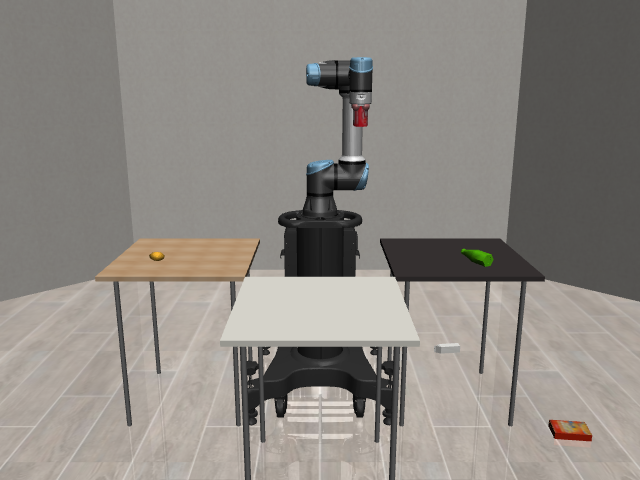

In [4]:
from PIL import Image

img = Image.open(f'examples/{EXAMPLE}/{IMG_NAME}')
img

In [6]:
se.queries_dict

{'on-table(milk-carton,wood-table)': 'Is the milk carton on the wood table?',
 'on-table(milk-carton,black-table)': 'Is the milk carton on the black table?',
 'on-table(milk-carton,white-table)': 'Is the milk carton on the white table?',
 'on-table(lemon,wood-table)': 'Is the lemon on the wood table?',
 'on-table(lemon,black-table)': 'Is the lemon on the black table?',
 'on-table(lemon,white-table)': 'Is the lemon on the white table?',
 'on-table(green-bottle,wood-table)': 'Is the green bottle on the wood table?',
 'on-table(green-bottle,black-table)': 'Is the green bottle on the black table?',
 'on-table(green-bottle,white-table)': 'Is the green bottle on the white table?',
 'on-table(loaf-of-bread,wood-table)': 'Is the loaf of bread on the wood table?',
 'on-table(loaf-of-bread,black-table)': 'Is the loaf of bread on the black table?',
 'on-table(loaf-of-bread,white-table)': 'Is the loaf of bread on the white table?',
 'on-table(red-box-of-cereal,wood-table)': 'Is the red box of cere

In [ ]:
se([img])

In [5]:
prob_map = se.estimate_state([img])
prob_map

  0%|          | 0/25 [00:00<?, ?it/s]

{'on-table(milk-carton,wood-table)': 0.75927734375,
 'on-table(milk-carton,black-table)': 0.75927734375,
 'on-table(milk-carton,white-table)': 0.85595703125,
 'on-table(lemon,wood-table)': 0.90380859375,
 'on-table(lemon,black-table)': 0.95458984375,
 'on-table(lemon,white-table)': 0.9638671875,
 'on-table(green-bottle,wood-table)': 0.86865234375,
 'on-table(green-bottle,black-table)': 0.92236328125,
 'on-table(green-bottle,white-table)': 0.962890625,
 'on-table(loaf-of-bread,wood-table)': 0.85693359375,
 'on-table(loaf-of-bread,black-table)': 0.88232421875,
 'on-table(loaf-of-bread,white-table)': 0.95751953125,
 'on-table(red-box-of-cereal,wood-table)': 0.77978515625,
 'on-table(red-box-of-cereal,black-table)': 0.83984375,
 'on-table(red-box-of-cereal,white-table)': 0.8916015625,
 'on-table(red-can-of-soda,wood-table)': 0.82763671875,
 'on-table(red-can-of-soda,black-table)': 0.9072265625,
 'on-table(red-can-of-soda,white-table)': 0.91943359375,
 'robot-gripper-empty()': 1.0,
 'robot-

In [ ]:
prob_map = se.estimate_state_par([img], batch_size=16)
prob_map

In [ ]:
state = set()
for pred, prob in prob_map.items():
    if prob > 0.5:
        state.add(pred)

state

In [ ]:
from PIL import ImageDraw, ImageFont

def display_res(query, output, img, save_path=None):
    img = img.copy()
    imd = ImageDraw.Draw(img)
    fnt = ImageFont.truetype("LiberationMono-Regular.ttf", 30)
    imd.text((28, 36), f'{query}: {output}', font=fnt, fill=(255, 0, 255))
    if save_path is None:
        img.show()
    else:
        img.save(save_path)

In [ ]:
from PIL import Image

image_files = [
    'start.png',
    'holding_milk.png',
    'holding_cereal.png',
    'milk_in_container.png',
    'cereal_in_container.png'
]
images = list(map(lambda imgf: Image.open(f'examples/{EXAMPLE}/{imgf}'), image_files))

In [ ]:
from tqdm.notebook import tqdm

for i, image in enumerate(tqdm(images)):
    prob_map = se.estimate_state_par([image], batch_size=4)
    for j, (pred, prob) in enumerate(tqdm(prob_map.items(), leave=False)):
        display_res(pred, f'{prob*100:.2f}%', image, save_path=f'demo/IMG{i}_pred{j}.png')

In [ ]:
for j, (pred, prob) in enumerate(tqdm(prob_map.items(), leave=False)):
    display_res(pred, f'{prob*100:.2f}%', images[-1])

In [ ]:
images[-1]

In [ ]:
img2 = Image.open(f'examples/apt0_body_state/kick-crop.jpeg')

In [ ]:
out = se.vqa_model([[img, img2], [img2, img]], ["describe the images", "describe the images please"])

In [ ]:
img2

In [ ]:
len(prob_map)

In [ ]:
se.queries_dict

In [ ]:
se.vqa_model('examples/apt0_body_state/right-foot-forward.jpeg', "Is the girl's left leg in front of her right leg?")

In [ ]:
probs = se.vqa_model('examples/apt0_body_state/right-foot-forward.jpeg', "Is the girl's left leg in front of her right leg?", get_probs=True)[-1]

In [ ]:
probs = se.vqa_model('examples/apt0_body_state/pre-jump.jpg', "Is the girl's left leg in front of her left leg?", get_probs=True)[-1]

In [ ]:
yes = probs[se.vqa_model.tokenizer.encode(['YES', 'yes', 'Yes'])].sum()
no = probs[se.vqa_model.tokenizer.encode(['NO', 'no', 'No'])].sum()

yes_prob = yes / (yes + no)
yes_prob.item()